In [58]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [59]:
data = []

path = "result.txt"

with open(path, "r") as f:
    for line in f:
        parts = line.strip().split()
        # Isolamento delle righe contenenti le  grandezze fisiche
        if len(parts) == 6:
            try:
                p = float(parts[0])
                pitch = float(parts[1])
                t_w = float(parts[2])
                t_f = float(parts[3])
                k = float(parts[4])
                err_k = float(parts[5])
               
                data.append([p , pitch , t_w ,t_f , k , err_k])
            except ValueError:
                continue

df = pd.DataFrame(data, columns=['pressione', 'pitch', 'T_water' , 'T_fuel' , 'k' , 'err_k'])

- Assumo che il reattore spento stia a 300 K sia in fuel che in acqua Cold Zero Power (CZP)

- definisco poi l'Hot Zero Power, cioè T_fuel = T_water ma a valori maggiori, magari 550K, cioè reattore pronto all'uso ma con ancora nessuna potenza prodotta

- infine serve il HFP = hot full power, cioè massima potenza


Per vedere una variazione:
$$\Delta\rho = \rho_2 - \rho_1 = \frac{k_2 - 1}{k_2} - \frac{k_1 - 1}{k_1} = \frac{k_2 - k_1}{k_1 \cdot k_2}$$


1. Temperature Defect (CZP $\rightarrow$ HZP) Nello stato CZP ($300\text{ K}$), il sistema è freddo. 
L'acqua ha la massima densità, offrendo la massima moderazione (spettro neutronico fortemente termico).
Scaldando il sistema allo stato HZP ($550\text{ K}$), la potenza è ancora nulla, quindi l'equilibrio termico impone $T_{fuel} = T_{water}$. 
    1) Il calo di reattività associato (Temperature Defect) è causato da due contributi: Moderator Temperature Coefficient (MTC) [Dominante]: All'aumentare della temperatura, la densità dell'acqua crolla. Questo causa due effetti: 
    - Diminuisce il potere rallentante ($\xi \Sigma_s$), indurendo lo spettro neutronico. Più neutroni vengono assorbiti nelle risonanze epitemiche dell'$^{238}\text{U}$ prima di termalizzare.
    - Aumenta il cammino libero medio neutronico, incrementando le fughe (leakage) verso i bordi del nocciolo.
    
    2) Effetto Doppler Isotermo [Minoritario]: Anche il combustibile si scalda da $300\text{ K}$ a $550\text{ K}$, causando un primo allargamento delle risonanze di assorbimento (Doppler broadening). 

2. Power Defect (HZP $\rightarrow$ HFP) Allo stato HZP, il reattore è critico e alle condizioni nominali di pressione/temperatura del fluido, ma genera $0\text{ W}$.Portando il reattore allo stato HFP (100% potenza nominale), la temperatura del moderatore resta approssimativamente costante ($T_{water} \approx 550\text{ K}$ media), ma per trasferire l'enorme calore generato per fissione nel pellet verso il fluido, si instaura un ripido gradiente termico. La temperatura media del combustibile $T_{fuel}$ schizza a valori elevati (es. $900\text{ K}$).Il calo di reattività associato (Power Defect) è dominato esclusivamente da un fenomeno: Fuel Temperature Coefficient (FTC) o Effetto Doppler Puro: L'aumento drammatico dell'agitazione termica dei nuclei di $^{238}\text{U}$ nel reticolo cristallino dell'$UO_2$ causa un allargamento (broadening) delle sezioni d'urto di cattura risonante. Sebbene l'integrale dell'area sotto la risonanza resti teoricamente costante, l'allargamento abbassa i picchi e allarga le code (riducendo il self-shielding spaziale ed energetico). Di conseguenza, aumenta drasticamente la probabilità che un neutrone venga catturato parassiticamente dall'$^{238}\text{U}$ durante il rallentamento.Il Power Defect rappresenta il feedback negativo vitale per la stabilità e la sicurezza intrinseca del reattore: all'aumentare della potenza, la fisica stessa del nocciolo "spegne" la reazione a catena. Questo valore definisce quanta reattività (es. estraendo le barre di controllo) l'operatore deve inserire per poter effettivamente far salire il reattore da $0$ al $100\%$ di potenza.


- Temperature Defect (Moderatore + Doppler base): Transizione da CZP a HZP.
$$\Delta\rho_{temp}=\frac{k_{HZP}-k_{CZP}}{k_{HZP}\cdot k_{CZP}}\cdot 10^5\quad [pcm]$$

- Power Defect (Effetto Doppler puro): Transizione da HZP a HFP.
$$\Delta\rho_{power}=\frac{k_{HFP}-k_{HZP}}{k_{HFP}\cdot k_{HZP}}\cdot 10^5\quad [pcm]$$



In [60]:
def calc_reactivity_defect(k1, std1, k2, std2):
    """Calcola il delta_rho in pcm e propaga l'errore statistico."""
    # Delta rho = (k2 - k1) / (k1 * k2)
    delta_rho = ((k2 - k1) / (k1 * k2)) * 1e5
    # Propagazione errore: sigma_rho = sqrt((sigma1/k1^2)^2 + (sigma2/k2^2)^2)
    err_rho = np.sqrt((std1 / k1**2)**2 + (std2 / k2**2)**2) * 1e5
    return delta_rho, err_rho

# Conversione pressione
df['pressione_atm'] = np.round(df['pressione'] / 101325.0, 2)

results = []
results_2=[]
ignorancy = -200.0  # Bias dati nucleari [pcm]

for (p_atm, pitch), group in df.groupby(['pressione_atm', 'pitch']):
    if len(group) != 3:
        continue 
    
    # Ordinamento: Stato 1 (Cold), Stato 2 (Hot Zero Power), Stato 3 (Full Power)
    g = group.sort_values(by=['T_water', 'T_fuel']).reset_index(drop=True)
    
    k1, std1 = g.loc[0, 'k'], g.loc[0, 'err_k']
    k2, std2 = g.loc[1, 'k'], g.loc[1, 'err_k']
    k3, std3 = g.loc[2, 'k'], g.loc[2, 'err_k']
    
    # Calcolo difetti di reattività
    rho_temp, err_temp = calc_reactivity_defect(k1, std1, k2, std2)
    rho_pow, err_pow = calc_reactivity_defect(k2, std2, k3, std3)

    print("Condizione di pressione =", p_atm , " e pitch : ", pitch )
    print(f"Reactivity Defect (Temp): {rho_temp :.1f} ± {err_temp :.1f} pcm")
    print(f"Reactivity Defect (Power): {rho_pow :.1f} ± {err_pow :.1f} pcm \n\n")
    
    # Reattività totale e k_eff finale (k_max)
    rho_tot = rho_temp + rho_pow + ignorancy
    err_tot = np.sqrt(err_temp**2 + err_pow**2)
    
    rho_max_val = rho_tot / 1e5
    k_max = 1 / (1 - rho_max_val)
    sigma_k = (err_tot / 1e5) * (k_max**2)
    
    results_2.append({
        'P [atm]': p_atm,
        'Pitch [cm]': pitch,
        'Δρ Temp [pcm]': f"{rho_temp:.1f} ± {err_temp:.1f}",
        'Δρ Pow [pcm]': f"{rho_pow:.1f} ± {err_pow:.1f}",
        'Δρ Tot [pcm]': f"{rho_tot:.1f} ± {err_tot:.1f}",
        'k_eff Final': f"{k_max:.5f} ± {sigma_k:.5f}"
    })

    results.append({

        'pressione_atm': p_atm,      
        'pitch': pitch/(2.05*np.sqrt(3)),
        'rho_tot': rho_tot,
        'err_tot': err_tot,
        'k_max': k_max,
        'sigma_k': sigma_k  })

# Generazione e visualizzazione tabella
df_res_2 = pd.DataFrame(results_2)
display(df_res_2)

df_res = pd.DataFrame(results)
df_res['pitch'] = df_res['pitch'].round(3)

Condizione di pressione = 1.0  e pitch :  0.355
Reactivity Defect (Temp): 354.2 ± 500.9 pcm
Reactivity Defect (Power): 354.1 ± 500.7 pcm 


Condizione di pressione = 1.0  e pitch :  0.391
Reactivity Defect (Temp): -344.0 ± 486.5 pcm
Reactivity Defect (Power): -688.4 ± 486.8 pcm 


Condizione di pressione = 1.0  e pitch :  0.444
Reactivity Defect (Temp): -1113.0 ± 393.5 pcm
Reactivity Defect (Power): -1393.3 ± 394.1 pcm 


Condizione di pressione = 1.0  e pitch :  0.533
Reactivity Defect (Temp): -1054.8 ± 229.5 pcm
Reactivity Defect (Power): -1953.9 ± 230.3 pcm 


Condizione di pressione = 1.0  e pitch :  0.621
Reactivity Defect (Temp): -1071.5 ± 121.2 pcm
Reactivity Defect (Power): -1894.5 ± 121.8 pcm 


Condizione di pressione = 1.0  e pitch :  0.71
Reactivity Defect (Temp): -957.2 ± 93.3 pcm
Reactivity Defect (Power): -1899.2 ± 93.7 pcm 


Condizione di pressione = 1.0  e pitch :  0.888
Reactivity Defect (Temp): -865.6 ± 60.2 pcm
Reactivity Defect (Power): -2030.5 ± 60.7 pcm 


Condi

,P [atm],Pitch [cm],Δρ Temp [pcm],Δρ Pow [pcm],Δρ Tot [pcm],k_eff Final
0,1.0,0.355,354.2 ± 500.9,354.1 ± 500.7,508.3 ± 708.3,1.00511 ± 0.00716
1,1.0,0.391,-344.0 ± 486.5,-688.4 ± 486.8,-1232.4 ± 688.2,0.98783 ± 0.00672
2,1.0,0.444,-1113.0 ± 393.5,-1393.3 ± 394.1,-2706.3 ± 556.9,0.97365 ± 0.00528
3,1.0,0.533,-1054.8 ± 229.5,-1953.9 ± 230.3,-3208.7 ± 325.1,0.96891 ± 0.00305
4,1.0,0.621,-1071.5 ± 121.2,-1894.5 ± 121.8,-3166.0 ± 171.8,0.96931 ± 0.00161
5,1.0,0.710,-957.2 ± 93.3,-1899.2 ± 93.7,-3056.4 ± 132.2,0.97034 ± 0.00125
6,1.0,0.888,-865.6 ± 60.2,-2030.5 ± 60.7,-3096.1 ± 85.5,0.96997 ± 0.00080
7,1.0,1.065,-2160.6 ± 64.0,-3113.8 ± 65.0,-5474.4 ± 91.2,0.94810 ± 0.00082
8,1.0,1.332,-3604.7 ± 53.3,-3528.0 ± 55.0,-7332.8 ± 76.6,0.93168 ± 0.00067
9,1.0,1.775,-3533.9 ± 38.6,-2347.4 ± 40.2,-6081.3 ± 55.8,0.94267 ± 0.00050


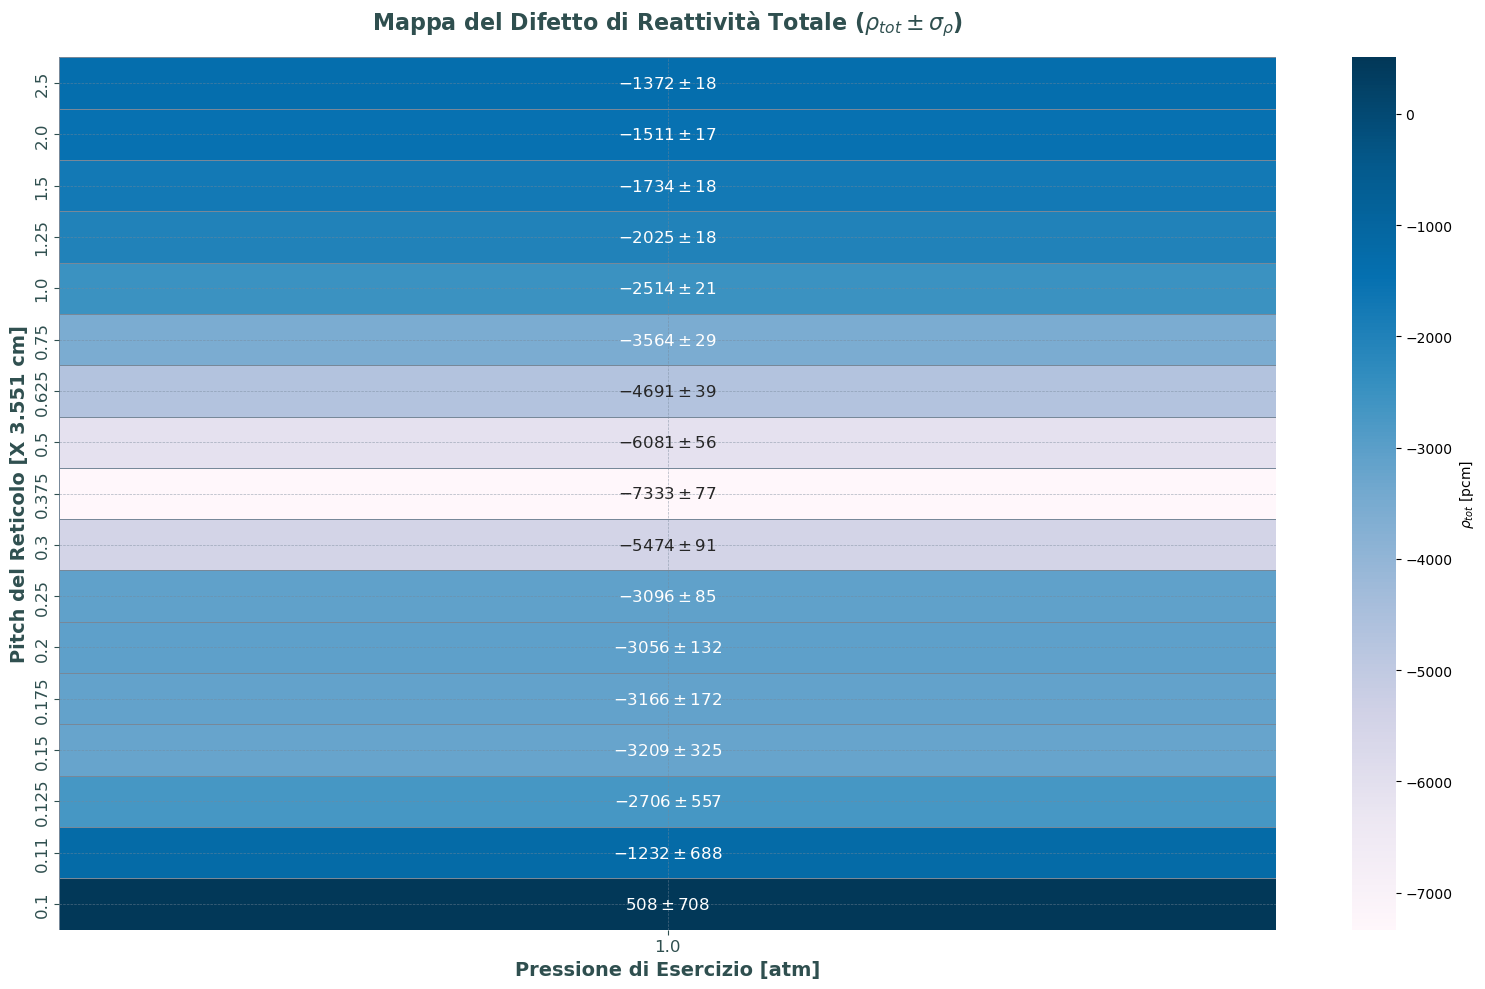

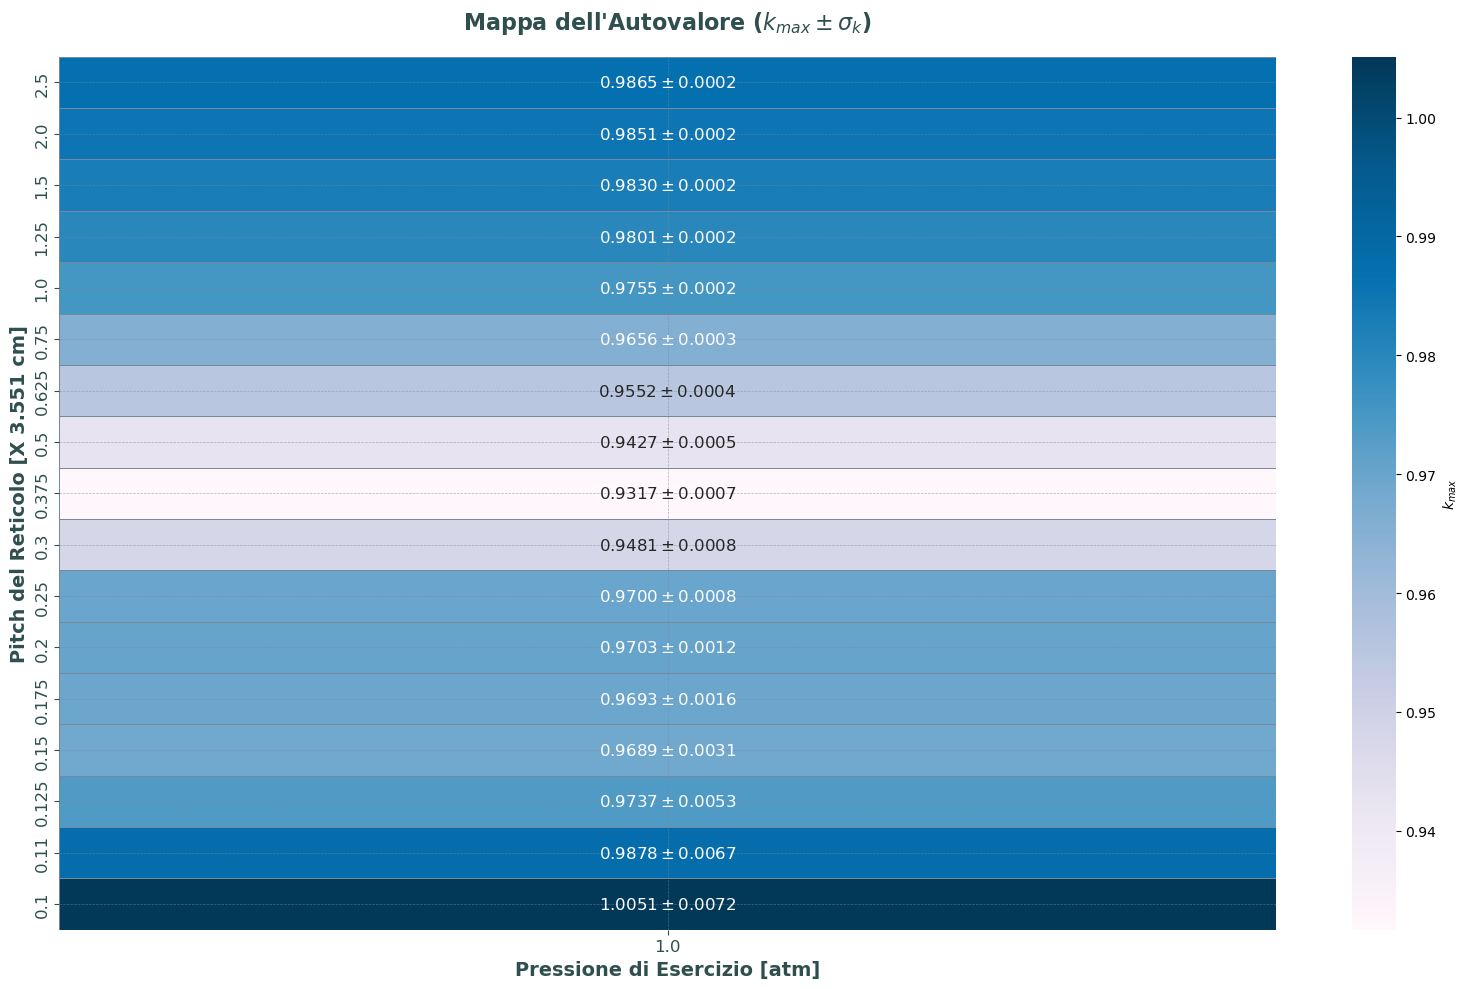

In [61]:

# matrici per Heatmap (assumendo df_res già calcolato)

pivot_rho = df_res.pivot(index='pitch', columns='pressione_atm', values='rho_tot')
pivot_err_rho = df_res.pivot(index='pitch', columns='pressione_atm', values='err_tot')

pivot_kmax = df_res.pivot(index='pitch', columns='pressione_atm', values='k_max')
pivot_err_kmax = df_res.pivot(index='pitch', columns='pressione_atm', values='sigma_k')

# Creazione delle matrici testuali di annotazione con sintassi LaTeX per il simbolo \pm
annot_rho = pd.DataFrame(
    [[f"${val:.0f} \pm {err:.0f}$" for val, err in zip(row_val, row_err)] 
     for row_val, row_err in zip(pivot_rho.values, pivot_err_rho.values)],
    index=pivot_rho.index, columns=pivot_rho.columns
)

annot_kmax = pd.DataFrame(
    [[f"${val:.4f} \pm {err:.4f}$" for val, err in zip(row_val, row_err)] 
     for row_val, row_err in zip(pivot_kmax.values, pivot_err_kmax.values)],
    index=pivot_kmax.index, columns=pivot_kmax.columns
)

lbl_props = {'fontsize': 14, 'fontweight': 'bold', 'color': '#2F4F4F'}
tit_props = {'fontsize': 16, 'fontweight': 'bold', 'color': '#2F4F4F'}
cmap_cool = "PuBu" 

def format_axes(ax):
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899', linewidth=0.5)
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899', linewidth=0.5)
    ax.tick_params(axis='x', colors='#2F4F4F', labelsize=12)
    ax.tick_params(axis='y', colors='#2F4F4F', labelsize=12)

# HEATMAP 1: Reattività Totale (rho_tot)
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot_rho, annot=annot_rho, fmt="", cmap=cmap_cool, cbar_kws={'label': r'$\rho_{tot}$ [pcm]'}, 
            ax=ax, annot_kws={"size": 12}, linewidths=0.5, linecolor='#778899')

ax.set_title(r"Mappa del Difetto di Reattività Totale ($\rho_{tot} \pm \sigma_{\rho}$)", **tit_props, pad=20)
ax.set_xlabel("Pressione di Esercizio [atm]", **lbl_props)
ax.set_ylabel("Pitch del Reticolo [X 3.551 cm]", **lbl_props)
ax.invert_yaxis()
format_axes(ax)
plt.tight_layout()
plt.show()

# HEATMAP 2: Autovalore Massimo (k_max)
fig, ax2 = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot_kmax, annot=annot_kmax, fmt="", cmap=cmap_cool, cbar_kws={'label': r'$k_{max}$'}, 
            ax=ax2, annot_kws={"size": 12}, linewidths=0.5, linecolor='#778899')

ax2.set_title(r"Mappa dell'Autovalore ($k_{max} \pm \sigma_{k}$)", **tit_props, pad=20)
ax2.set_xlabel("Pressione di Esercizio [atm]", **lbl_props)
ax2.set_ylabel("Pitch del Reticolo [X 3.551 cm]", **lbl_props)
ax2.invert_yaxis()
format_axes(ax2)
plt.tight_layout()
plt.show()

In [62]:
# Salvataggio di tutti i k_max, pitch, pressione e delta rho su file
filename = "k_max.txt"

with open(filename, "w") as f:
    # Intestazione del file
    f.write(f"{'Pressione [atm]':<18} | {'Pitch':<10} | {'k_max +/- sigma_k':<22} | {'Delta_rho +/- err_rho [pcm]'}\n")
    f.write("-" * 85 + "\n")
    
    # Iterazione su tutte le righe del DataFrame
    for _, row in df_res.iterrows():
        p_atm = row['pressione_atm']
        pitch = row['pitch']
        k_max = row['k_max']
        sig_k = row['sigma_k']
        rho = row['rho_tot']
        err_rho = row['err_tot']
        
        # Scrittura formattata
        f.write(f"{p_atm:<18.2f} | {pitch:<10.3f} | {k_max:.5f} +/- {sig_k:.5f} | {rho:.1f} +/- {err_rho:.1f}\n")

print(f"Dati salvati con successo in {filename}")

Dati salvati con successo in k_max.txt


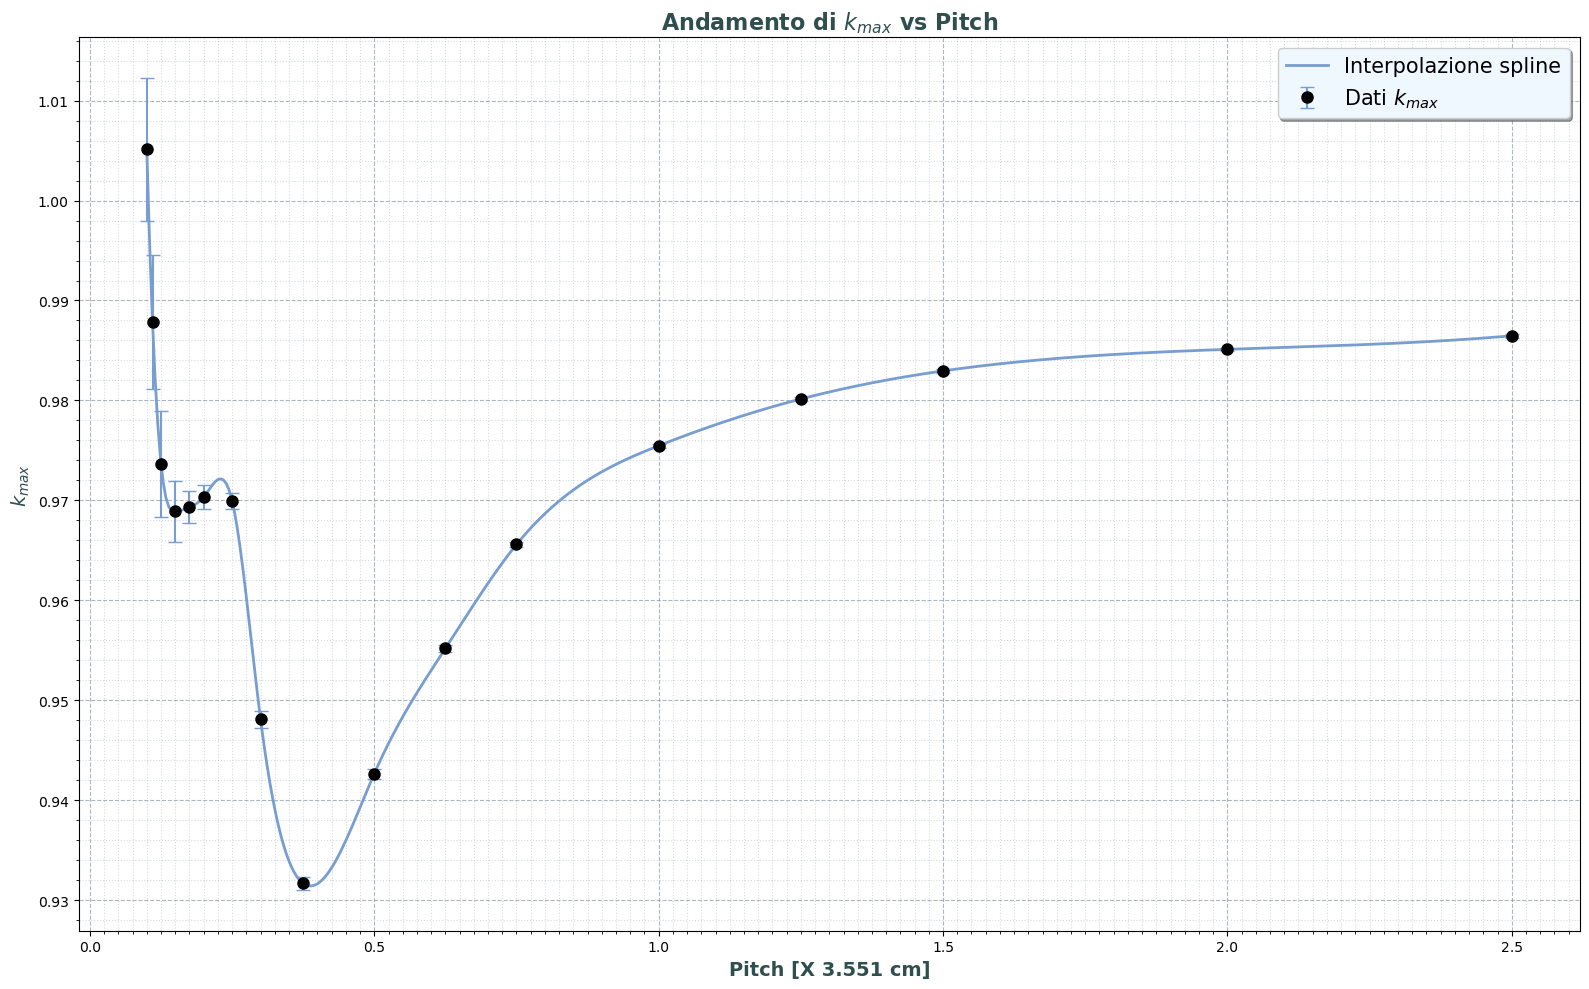

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Estrazione e ordinamento dei dati
x = df_res['pitch'].values
y_k = df_res['k_max'].values
err_k = df_res['sigma_k'].values

# Ordinamento necessario per la spline
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y_k[sort_idx]
err_sorted = err_k[sort_idx]

# Creazione della curva smooth (Spline cubica)
x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), 500)
spline = make_interp_spline(x_sorted, y_sorted, k=3)
y_smooth = spline(x_smooth)

# Proprietà grafiche
lbl_props = {'fontsize': 14, 'fontweight': 'bold', 'color': '#2F4F4F'}
tit_props = {'fontsize': 16, 'fontweight': 'bold', 'color': '#2F4F4F'}
legend_props = {'loc': 'best', 'frameon': True, 'shadow': True, 'fontsize': 15, 'facecolor': '#F0F8FF'}

# Generazione del Plot
fig, ax = plt.subplots(figsize=(16, 10))

# Plot curva smooth
ax.plot(x_smooth, y_smooth, '-', color='#789DD1', linewidth=2, label='Interpolazione spline')

# Plot punti sperimentali con barre d'errore
ax.errorbar(x_sorted, y_sorted, yerr=err_sorted, fmt='o', color='#000000', 
            ecolor='#789DD1', capsize=5, markersize=8, label='Dati $k_{max}$')

from matplotlib.ticker import AutoMinorLocator

# Formattazione assi e titolo
ax.set_xlabel('Pitch [X 3.551 cm]', **lbl_props)
ax.set_ylabel('$k_{max}$', **lbl_props)
ax.set_title('Andamento di $k_{max}$ vs Pitch', **tit_props)

# Controllo manuale della densità dei tick minori 
ax.xaxis.set_minor_locator(AutoMinorLocator(20))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

# Setup della griglia
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax.legend(**legend_props)

plt.tight_layout()

plt.show()